In [1]:
%%writefile ../data/download_data.py

import os
import shutil
from pathlib import Path
import kagglehub

def download_data(target_folder="../data", filename="creditcard.csv"):
    
    target_path = Path(target_folder)
    target_path.mkdir(parents=True, exist_ok=True)
    
    destination_file = target_path / filename
    
    if destination_file.exists():
        print(f"[INFO] File already exists at: {destination_file}. Skipping download.")
        return str(destination_file)

    print("[INFO] Downloading dataset from Kaggle using kagglehub...")
    try:
        downloaded_dir = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
        downloaded_path = Path(downloaded_dir)
        
        csv_files = list(downloaded_path.glob("*.csv"))
        
        if not csv_files:
            raise FileNotFoundError("No CSV file found in the downloaded Kaggle dataset.")
        
        shutil.copy(csv_files[0], destination_file)
        print(f"[SUCCESS] Dataset successfully saved to: {destination_file}")
        return str(destination_file)
        
    except Exception as e:
        print(f"[ERROR] Failed to download dataset: {e}")
        print("[TIP] Make sure you have installed kagglehub: pip install kagglehub")
        return None



Overwriting ../data/download_data.py


In [2]:
download_data()

NameError: name 'download_data' is not defined

In [6]:
%%writefile ../src/datasets.py

## create the data sets

import torch
import pandas as pd 
import os

from sklearn.model_selection import train_test_split 
from torch.utils.data import DataLoader , TensorDataset
from sklearn.preprocessing import StandardScaler

cpu_count = os.cpu_count()

def load_data(
    path = '../data/creditcard.csv' ,
    batch_size = 1024 , 
    test_size = 0.3 ,
    random_state = 42 ,
    cpu_count = cpu_count
):
    df  = pd.read_csv(path)
    
    X = df.drop('Class' , axis = 1)
    y = df['Class']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=random_state)

    X_train = torch.tensor(X_train , dtype=torch.float32)
    y_train = torch.tensor(y_train.to_numpy() , dtype=torch.float32)

    X_test = torch.tensor(X_test , dtype=torch.float32)
    y_test = torch.tensor(y_test.to_numpy() , dtype=torch.float32)

    train_dataset = TensorDataset(X_train , y_train)
    test_dataset = TensorDataset(X_test , y_test)

    train_loader = DataLoader(
        train_dataset ,
        batch_size=batch_size ,
        shuffle=True ,
        num_workers=cpu_count,
        pin_memory=True
        
    )

    test_loader = DataLoader(
        test_dataset ,
        batch_size= batch_size ,
        shuffle= False ,
        num_workers=cpu_count,
        pin_memory=True
    )

    input_dim = X_train.shape[1]

    return train_loader , test_loader , input_dim


Overwriting ../src/datasets.py


In [7]:
load_data()

NameError: name 'load_data' is not defined

In [8]:
%%writefile model.py

# create a class for our model
import torch
import torch.nn as nn

class FraudClassifierMLP(nn.Module):
    def __init__(self, input_dim, hidden_unit=16, output_dim=1):
        super().__init__()
        
        self.layer_stack = nn.Sequential(
            nn.Linear(in_features=input_dim, out_features=hidden_unit),
            nn.ReLU(),
            nn.Linear(in_features=hidden_unit, out_features=output_dim)
        )
        
    def forward(self, x):
        return self.layer_stack(x)

Overwriting model.py


In [48]:
# %%writefile ../src/train.py
## Now were going to train our model 
import torch 
from torch import nn 
from model import FraudClassifierMLP
from datasets import load_data


def accuracy_fn(y_true , y_pred ):
    correct = torch.eq(y_true , y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc
    

device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_loader , test_loader , input_dim = load_data() 

model = FraudClassifierMLP(input_dim=input_dim).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters() , lr= 0.01)

def train_model(epochs : int = 20 ,train_dataloader = train_loader ,loss_fn = loss_fn ,optimizer = optimizer  ,
                device = device  , accuracy_fn = accuracy_fn):

    train_loss_list = []
    train_acc_list = []
    
    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        running_acc = 0.0

        for batch , (X_batch , y_batch) in enumerate(train_dataloader):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_batch = y_batch.unsqueeze(1)

            y_pred_logits = model(X_batch)
            y_pred = torch.round(torch.sigmoid(y_pred_logits))

            loss = loss_fn(y_pred_logits , y_batch)
            acc = accuracy_fn(y_true= y_batch , y_pred = y_pred )

            running_loss += loss.item()
            running_acc += acc
            
            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            epoch_loss = running_loss / len(train_dataloader)
            epoch_acc = running_acc / len(train_dataloader)

        train_loss_list.append(epoch_loss)
        train_acc_list.append(epoch_acc)

        if epoch % 10 == 0 :
            print(f"Epoch: {epoch+1:03d}/{epochs} | Loss: {epoch_loss:.5f} | Acc: {epoch_acc:.2f}%")

    return train_acc_list , train_loss_list 

In [49]:
%%time

train_acc_list , train_loss_list  = train_model()

Epoch: 001/20 | Loss: 0.18417 | Acc: 99.49%
Epoch: 011/20 | Loss: 0.00614 | Acc: 99.87%
CPU times: total: 1min 33s
Wall time: 1min 26s


In [51]:
# %%writefile ../src/utils.py

import torch
import os 
import matplotlib.pyplot as plt


def save_model(model):
    if not os.path.exists('../models'):
        os.makedirs('../models')
        print('models folder created')
        
    torch.save(model.state_dict() , '../models/model.pth')
    print("✅ Model Saved")

def plotresults(train_accs , train_losses):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Accuracy', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

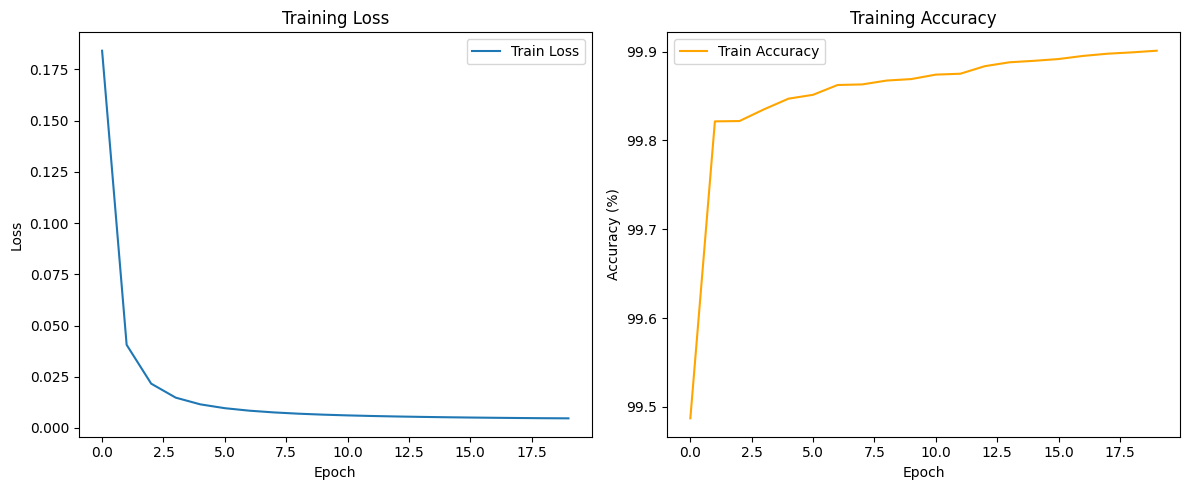

In [52]:
plotresults(train_acc_list, train_loss_list)

In [53]:
save_model(model)

✅ Model Saved


In [60]:
%%writefile ../src/predict.py

import torch 
from model import FraudClassifierMLP
from datasets import load_data


device = 'cuda' if torch.cuda.is_available() else 'cpu'

def accuracy_fn(y_true , y_pred ):
    correct = torch.eq(y_true , y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc
loss_fn = nn.BCEWithLogitsLoss()

train_loader , test_loader , input_dim = load_data() 
model = FraudClassifierMLP(input_dim=input_dim).to(device)

model.load_state_dict(torch.load('../models/model.pth', map_location=device))

def predict(test_dataloader=test_loader):
    model.eval()
    test_acc_running = 0.0
    test_loss_running = 0.0

    with torch.no_grad():
        for batch, (X_test, y_test) in enumerate(test_dataloader):
            X_test = X_test.to(device)
            y_test = y_test.float().to(device).unsqueeze(1)

            y_logits = model(X_test)
            y_pred = torch.round(torch.sigmoid(y_logits))

            loss = loss_fn(y_logits, y_test)
            test_acc = accuracy_fn(y_true=y_test, y_pred=y_pred)

            test_acc_running += test_acc
            test_loss_running += loss.item()

    final_test_acc = test_acc_running / len(test_dataloader)
    final_test_loss = test_loss_running / len(test_dataloader)

    print(f'test acc : {final_test_acc} | test loss : {final_test_loss}')

Writing ../src/predict.py


In [58]:
predict()

test acc : 99.92047155688623 | test loss : 0.004049929353118523


In [59]:
predict(train_loader)

test acc : 99.90221838896021 | test loss : 0.004634797569204108
